In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import sys
sys.path.append('/nevis/wanaka/share/standon/GRAMS/GramsOccupancy')
from scripts.extract_df import extract_all_events
from scripts.config import PARTICLE_DICT

plt.style.use('~/latex-cm.mplstyle')
colors = sns.color_palette('colorblind')

particle_names = {k: v[0] for k, v in PARTICLE_DICT.items()}

In [2]:
# Load unified events DataFrame and filter to photon primaries.
#
# n_comptons per event = number of "compt" entries in the comma-separated,
# chronologically-ordered daughter_processes column (direct daughters only).
#
# Containment categories come from extract_df._classify_containment and are
# defined event-wide over ALL direct daughters (not just Compton daughters):
#   "contained" = first daughter in active LAr AND all daughters + primary
#                 endpoint in active LAr
#   "escaped"   = first daughter in active LAr but some leakage later
#   "incomplete"= has hits but first daughter not in active LAr
#   "inactive"  = no LAr hits
#
# The original comptons.ipynb classified based on the first *Compton* daughter
# specifically and required n_comptons >= 1. Events with only photoabsorption
# or pair conversion (no Compton scattering) got dumped into the "inactive"
# bucket. We reproduce that here by requiring n_comptons > 0 for contained
# and escaped — without this, pure "phot" events inside active LAr would pile
# up in the 0-Compton bin of "contained".

events_df = extract_all_events()
photons = events_df[events_df['particle'] == 'photon'].copy()

photons['n_comptons'] = (
    photons['daughter_processes']
    .fillna('')
    .str.split(',')
    .apply(lambda lst: sum(p == 'compt' for p in lst))
)

has_compt = photons['n_comptons'] > 0

def _to_dict(sub):
    """event_index -> (n_comptons, primary_energy)"""
    return dict(zip(sub['event_index'], zip(sub['n_comptons'], sub['primary_energy'])))

contained = _to_dict(photons[(photons['containment'] == 'contained') & has_compt])
escaped = _to_dict(photons[(photons['containment'] == 'escaped') & has_compt])
# everything else (no hits, first daughter outside active, or no Compton at all)
inactive = _to_dict(photons[~photons['event_index'].isin(set(contained) | set(escaped))])

print(f"Contained in active LAr:              {len(contained)}")
print(f"Escaped active LAr:                   {len(escaped)}")
print(f"Skipped (no Compton in active LAr):   {len(inactive)}")

[INFO] Extracting electr (10000 events)...[INFO] Extracting positr (10000 events)...

[INFO] Extracting mumins (10000 events)...
[INFO] Extracting proton (10000 events)...
[INFO] Extracting muplus (10000 events)...[INFO] Extracting photon (10000 events)...

[INFO] Extracting neutro (10000 events)...
[INFO] Extracting he---4 (10000 events)...
[INFO]   photon done (10000 events)
[INFO]   neutro done (10000 events)
[INFO]   electr done (10000 events)
[INFO]   mumins done (10000 events)
[INFO]   muplus done (10000 events)
[INFO]   positr done (10000 events)
[INFO]   proton done (10000 events)
[INFO]   he---4 done (10000 events)
[INFO] Saved 80000 rows to /nevis/wanaka/data/standon/GramsOccupancy/psf/pkl/events.parquet
Contained in active LAr:              180
Escaped active LAr:                   689
Skipped (no Compton in active LAr):   9131


In [3]:
# extract arrays from dicts for plotting
contained_counts = np.array([v[0] for v in contained.values()])
escaped_counts = np.array([v[0] for v in escaped.values()])
inactive_counts = np.array([v[0] for v in inactive.values()])
contained_energy = np.array([v[1] for v in contained.values()])
escaped_energy = np.array([v[1] for v in escaped.values()])

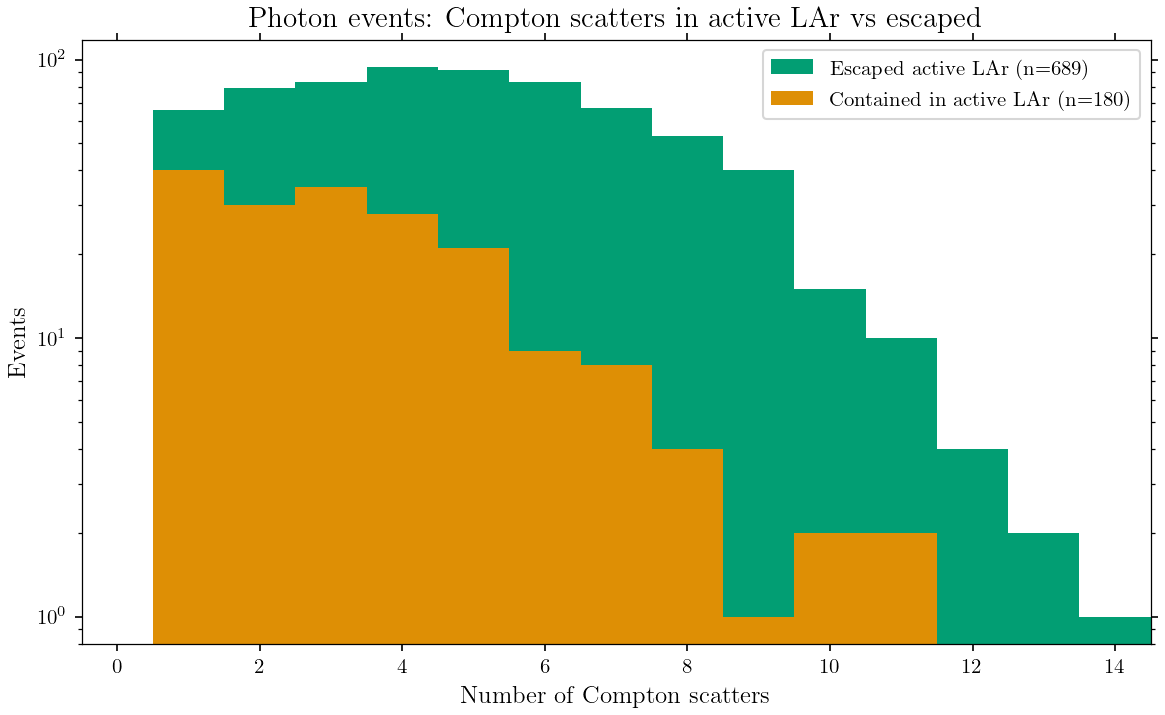

In [4]:
# histogram of Compton scatter counts: contained vs escaped
all_counts = np.concatenate([contained_counts, escaped_counts])
max_count = int(all_counts.max()) if len(all_counts) > 0 else 10
bins = np.arange(-0.5, max_count + 1.5, 1)

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(escaped_counts, bins=bins, histtype='stepfilled', alpha=1,
        color=colors[2], linewidth=1.2,
        label=f'Escaped active LAr (n={len(escaped_counts)})')
ax.hist(contained_counts, bins=bins, histtype='stepfilled', alpha=1,
        color=colors[1], linewidth=1.2,
        label=f'Contained in active LAr (n={len(contained_counts)})')

ax.set_xlabel('Number of Compton scatters')
ax.set_ylabel('Events')
ax.set_title('Photon events: Compton scatters in active LAr vs escaped')
ax.legend()
ax.set_yscale('log')
ax.set_xlim(-0.5, max_count + 0.5)

fig.tight_layout()
plt.show()

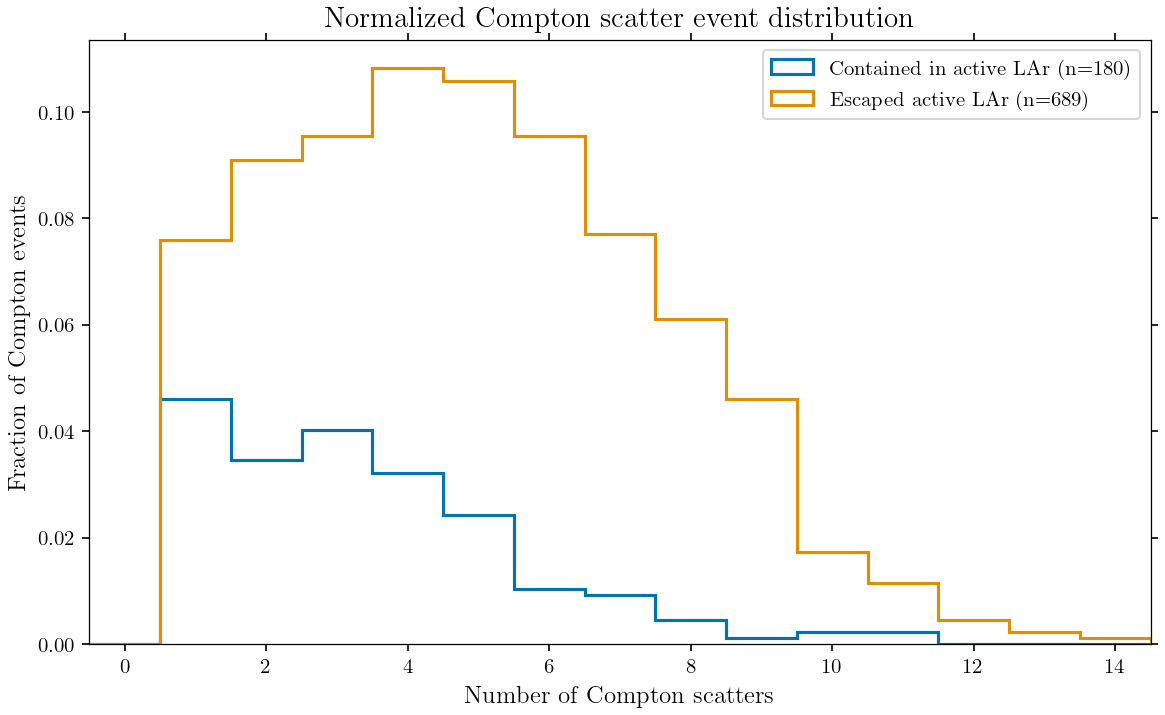

: 

In [ ]:
# normalized by total number of compton-interacting events (contained + escaped)
total = len(contained_counts) + len(escaped_counts)

fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(contained_counts, bins=bins, histtype='step',
        color=colors[0], linewidth=1.5, weights=np.ones_like(contained_counts) / total,
        label=f'Contained in active LAr (n={len(contained_counts)})')
ax.hist(escaped_counts, bins=bins, histtype='step',
        color=colors[1], linewidth=1.5, weights=np.ones_like(escaped_counts) / total,
        label=f'Escaped active LAr (n={len(escaped_counts)})')

ax.set_xlabel('Number of Compton scatters')
ax.set_ylabel('Fraction of Compton events')
ax.set_title('Normalized Compton scatter event distribution')
ax.legend()
ax.set_xlim(-0.5, max_count + 0.5)

fig.tight_layout()
plt.show()

In [ ]:
# print summary statistics
for label, arr in [("Contained in active LAr", contained_counts),
                   ("Escaped active LAr", escaped_counts),
                   ("No Compton in active LAr", inactive_counts)]:
    print(f"{label}: {len(arr)} events")
    if len(arr) > 0:
        print(f"  Mean Compton scatters: {arr.mean():.2f}")
        print(f"  Median:               {np.median(arr):.1f}")
        print(f"  Max:                  {arr.max()}")
    else:
        print(f"  (no events)")
    print()

Contained in active LAr: 180 events
  Mean Compton scatters: 3.42
  Median:               3.0
  Max:                  11

Escaped active LAr: 689 events
  Mean Compton scatters: 4.95
  Median:               5.0
  Max:                  14

No Compton in active LAr: 9131 events
  Mean Compton scatters: 2.00
  Median:               1.0
  Max:                  16



: 

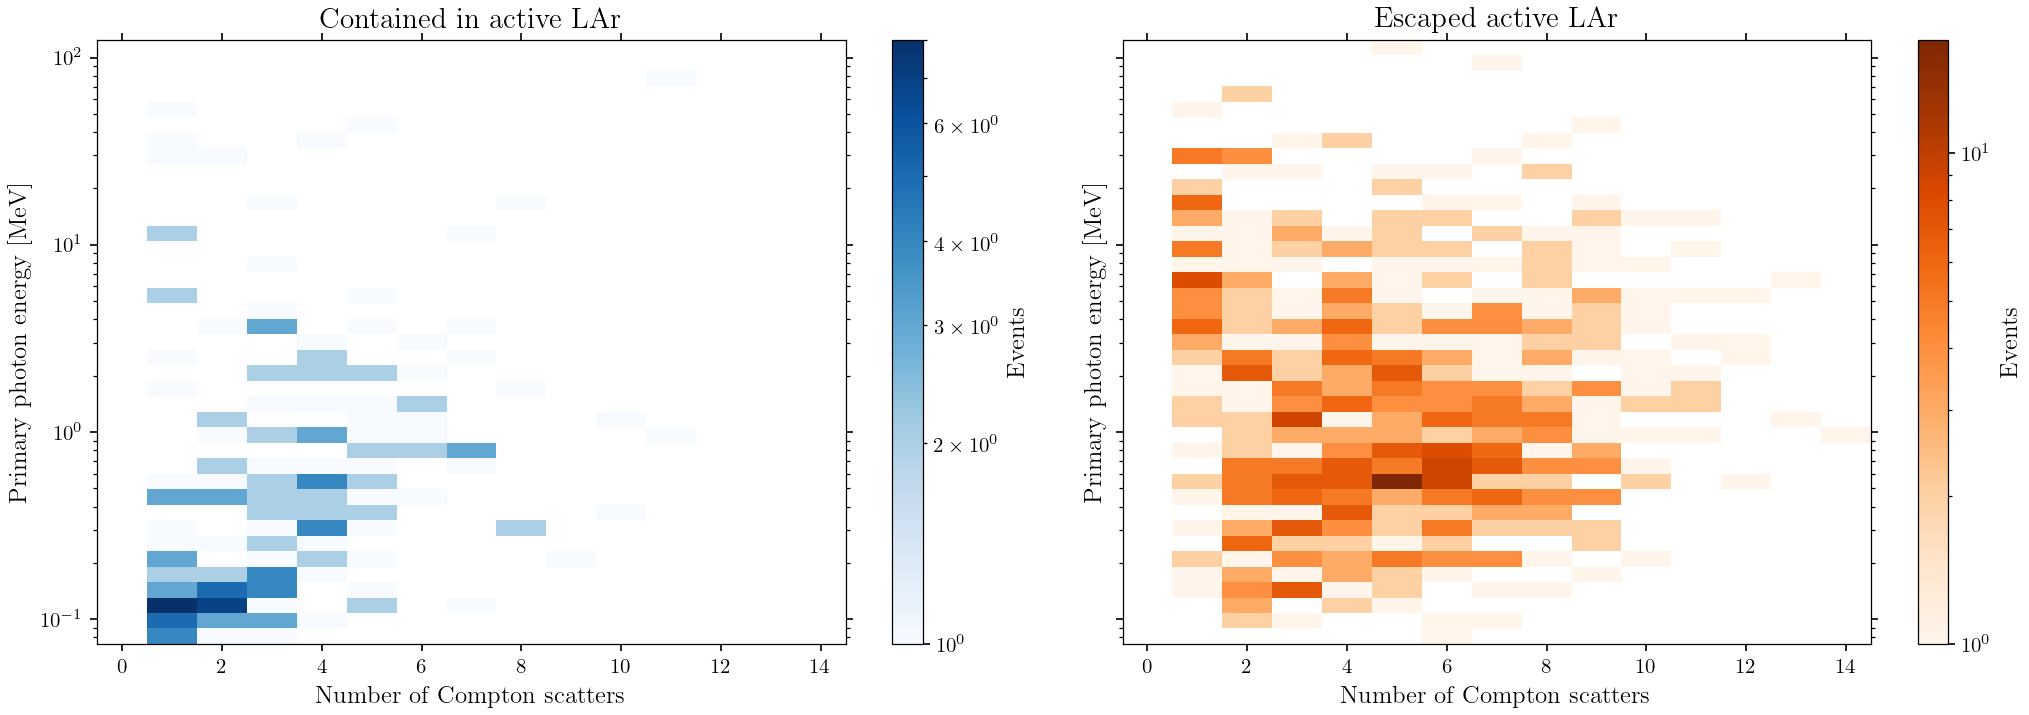

: 

In [ ]:
# 2D histogram: number of Compton scatters (x) vs primary energy (y)
from matplotlib.colors import LogNorm

all_energies = np.concatenate([contained_energy, escaped_energy])
all_comptons = np.concatenate([contained_counts, escaped_counts])
all_labels = np.concatenate([np.zeros(len(contained_counts)),
                             np.ones(len(escaped_counts))])

# compton bins (integer) and energy bins (log-spaced)
c_max = int(all_comptons.max())
c_bins = np.arange(-0.5, c_max + 1.5, 1)
valid = all_energies[np.isfinite(all_energies) & (all_energies > 0)]
e_bins = np.geomspace(valid.min(), valid.max(), 40)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True, sharey=True)

for ax, label_val, title, cmap in zip(
    axes,
    [0, 1],
    ['Contained in active LAr', 'Escaped active LAr'],
    ['Blues', 'Oranges']
):
    mask = all_labels == label_val
    h = ax.hist2d(all_comptons[mask], all_energies[mask],
                  bins=[c_bins, e_bins], norm=LogNorm(), cmap=cmap)
    fig.colorbar(h[3], ax=ax, label='Events')
    ax.set_yscale('log')
    ax.set_xlabel('Number of Compton scatters')
    ax.set_ylabel('Primary photon energy [MeV]')
    ax.set_title(title)

fig.tight_layout()
plt.show()

: 